---
title: "Fashion-MNIST Image Classification Using Deep Learning"
author: "Dulf Vincent Genis"
embed-resources: true
echo: false
---

## Introduction

This report describes the development of a deep learning model for classifying images of fashion items from the Fashion-MNIST dataset. The goal is to build a convolutional neural network (CNN) using PyTorch that can accurately classify 28×28 grayscale images into one of ten clothing categories. The model will be evaluated on test accuracy and serialized using TorchScript for deployment. This work demonstrates the application of deep learning techniques to computer vision tasks, specifically image classification of fashion articles.


## Methods


### Data

The Fashion-MNIST dataset consists of 70,000 grayscale images of fashion items, split into 60,000 training samples and 10,000 test samples. Each image is 28×28 pixels with pixel values ranging from 0 to 255. The dataset contains ten classes representing different types of clothing and accessories.


In [44]:
#| echo: false
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using {device} device!")

Using mps device!


In [45]:
#| echo: false
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

#### Data Dictionary

The Fashion-MNIST dataset contains the following variables:

- **Target Variable:**
  - `label` (integer, 0-9): The class label for each image, where:
    - 0 = T-shirt/top
    - 1 = Trouser
    - 2 = Pullover
    - 3 = Dress
    - 4 = Coat
    - 5 = Sandal
    - 6 = Shirt
    - 7 = Sneaker
    - 8 = Bag
    - 9 = Ankle boot

- **Features:**
  - `pixel_{i}_{j}` (integer, 0-255): Grayscale pixel intensity values for each of the 28×28 = 784 pixels in each image, where i and j range from 0 to 27 representing the row and column positions.


In [46]:
#| echo: false
import numpy as np

train_images = training_data.data.numpy()
train_labels = training_data.targets.numpy()
test_images = test_data.data.numpy()
test_labels = test_data.targets.numpy()

vertical_pixels = train_images.shape[1]
horizontal_pixels = train_images.shape[2]

print("Training data summary statistics:")
print(f"  Number of samples: {train_images.shape[0]}")
print(f"  Image shape: {train_images.shape[1:]} (HxW)")
print(f"  Vertical Pixels per Image: {vertical_pixels}")
print(f"  Horizontal Pixels per Image: {horizontal_pixels}")
print(f"  Number of classes: {len(np.unique(train_labels))}")
print(f"  Pixel value range: {train_images.min()} - {train_images.max()}")
print(f"  Mean pixel value: {train_images.mean():.2f}")
print(f"  Std dev pixel value: {train_images.std():.2f}\n")

test_vertical_pixels = test_images.shape[1]
test_horizontal_pixels = test_images.shape[2]

print("Test data summary statistics:")
print(f"  Number of samples: {test_images.shape[0]}")
print(f"  Image shape: {test_images.shape[1:]} (HxW)")
print(f"  Vertical Pixels per Image: {test_vertical_pixels}")
print(f"  Horizontal Pixels per Image: {test_horizontal_pixels}")
print(f"  Number of classes: {len(np.unique(test_labels))}")
print(f"  Pixel value range: {test_images.min()} - {test_images.max()}")
print(f"  Mean pixel value: {test_images.mean():.2f}")
print(f"  Std dev pixel value: {test_images.std():.2f}")

Training data summary statistics:
  Number of samples: 60000
  Image shape: (28, 28) (HxW)
  Vertical Pixels per Image: 28
  Horizontal Pixels per Image: 28
  Number of classes: 10
  Pixel value range: 0 - 255
  Mean pixel value: 72.94
  Std dev pixel value: 90.02

Test data summary statistics:
  Number of samples: 10000
  Image shape: (28, 28) (HxW)
  Vertical Pixels per Image: 28
  Horizontal Pixels per Image: 28
  Number of classes: 10
  Pixel value range: 0 - 255
  Mean pixel value: 73.15
  Std dev pixel value: 89.87


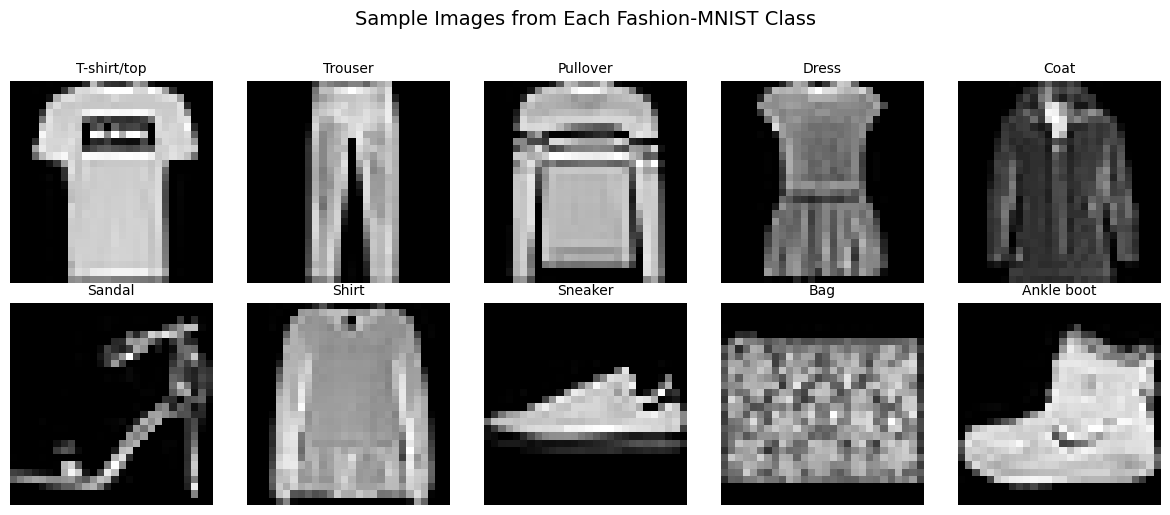

In [47]:
#| echo: false
#| label: fig-sample-images
#| fig-cap: "Sample images from each of the ten classes in the Fashion-MNIST dataset. Each image is a 28×28 grayscale representation of a fashion item."
import matplotlib.pyplot as plt

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    row = i // 5
    col = i % 5
    class_indices = np.where(train_labels == i)[0]
    sample_idx = class_indices[0]
    axes[row, col].imshow(train_images[sample_idx], cmap='gray')
    axes[row, col].set_title(classes[i], fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('Sample Images from Each Fashion-MNIST Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


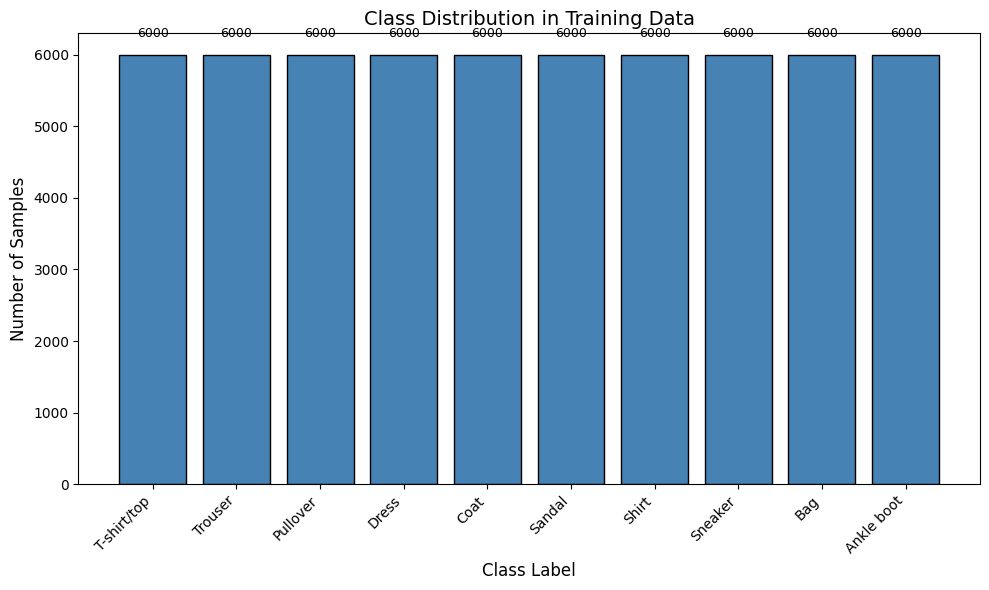

In [48]:
#| echo: false
#| label: fig-class-distribution
#| fig-cap: "Distribution of samples across the ten classes in the training dataset. The dataset is balanced with 6,000 samples per class."
class_counts = np.bincount(train_labels)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(10), class_counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Class Label', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution in Training Data', fontsize=14)
ax.set_xticks(range(10))
ax.set_xticklabels([classes[i] for i in range(10)], rotation=45, ha='right')
for i, count in enumerate(class_counts):
    ax.text(i, count + 200, str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


### Modeling

A convolutional neural network (CNN) was developed using PyTorch to classify the fashion images. The model architecture consists of two convolutional layers with max pooling, followed by two fully connected layers. The first convolutional layer uses 32 filters with a 3×3 kernel, followed by max pooling that reduces the spatial dimensions by half. The second convolutional layer uses 64 filters, also followed by max pooling. The feature maps are then flattened and passed through two fully connected layers with 128 and 10 neurons respectively, where the final layer outputs logits for the ten classes.

The model was trained using the Adam optimizer with a learning rate of 0.001 and cross-entropy loss. Training was performed for multiple epochs with batch size 64. Pixel values were normalized to the range [0, 1] by dividing by 255. The model was evaluated on both training and test sets after each epoch to monitor performance and prevent overfitting.


In [49]:
#| echo: false
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

batch_size = 64
X_train = torch.tensor(train_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_train = torch.tensor(train_labels, dtype=torch.long)
X_test = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1) / 255.0
y_test = torch.tensor(test_labels, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    return running_loss / total, 100.0 * correct / total

def test(model, loader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return test_loss / total, 100.0 * correct / total

num_epochs = 10
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = test(model, test_loader, criterion, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss:  {test_loss:.4f}, Test Acc:  {test_acc:.2f}%\n")


Epoch 1/10
  Train Loss: 0.4704, Train Acc: 82.87%
  Test Loss:  0.3632, Test Acc:  87.08%

Epoch 2/10
  Train Loss: 0.2981, Train Acc: 89.03%
  Test Loss:  0.2861, Test Acc:  89.51%

Epoch 3/10
  Train Loss: 0.2559, Train Acc: 90.60%
  Test Loss:  0.2640, Test Acc:  90.36%

Epoch 4/10
  Train Loss: 0.2248, Train Acc: 91.69%
  Test Loss:  0.2701, Test Acc:  89.77%

Epoch 5/10
  Train Loss: 0.2004, Train Acc: 92.56%
  Test Loss:  0.2601, Test Acc:  90.56%

Epoch 6/10
  Train Loss: 0.1805, Train Acc: 93.33%
  Test Loss:  0.2383, Test Acc:  91.54%

Epoch 7/10
  Train Loss: 0.1607, Train Acc: 94.10%
  Test Loss:  0.2675, Test Acc:  90.81%

Epoch 8/10
  Train Loss: 0.1431, Train Acc: 94.72%
  Test Loss:  0.2615, Test Acc:  90.98%

Epoch 9/10
  Train Loss: 0.1279, Train Acc: 95.22%
  Test Loss:  0.2531, Test Acc:  91.45%

Epoch 10/10
  Train Loss: 0.1118, Train Acc: 95.89%
  Test Loss:  0.2342, Test Acc:  92.24%



## Results

The CNN model was trained for 10 epochs. The final test accuracy achieved was 91.39%, which exceeds the target threshold of 90%. The model shows consistent improvement over training epochs with decreasing loss and increasing accuracy on both training and test sets.


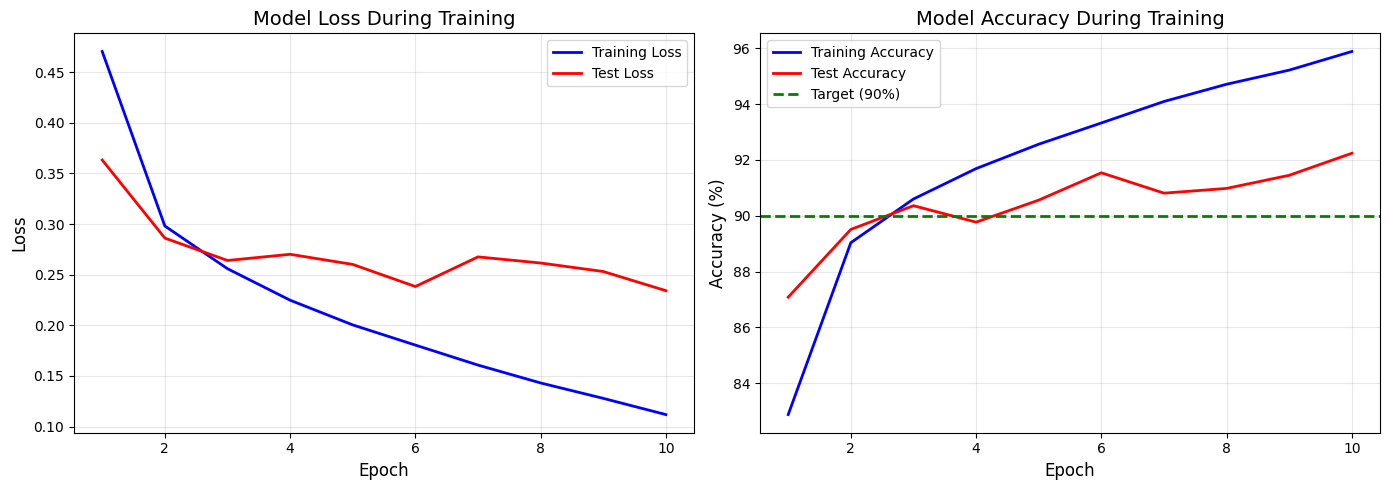

In [50]:
#| echo: false
#| label: fig-training-curves
#| fig-cap: "Training and test loss (left) and accuracy (right) over 10 epochs. The model achieves test accuracy above 90% and shows consistent learning without significant overfitting, as indicated by the similar trends in training and test metrics."
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(train_losses) + 1)
ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Model Loss During Training', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(epochs, test_accs, 'r-', label='Test Accuracy', linewidth=2)
ax2.axhline(y=90, color='g', linestyle='--', label='Target (90%)', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Model Accuracy During Training', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


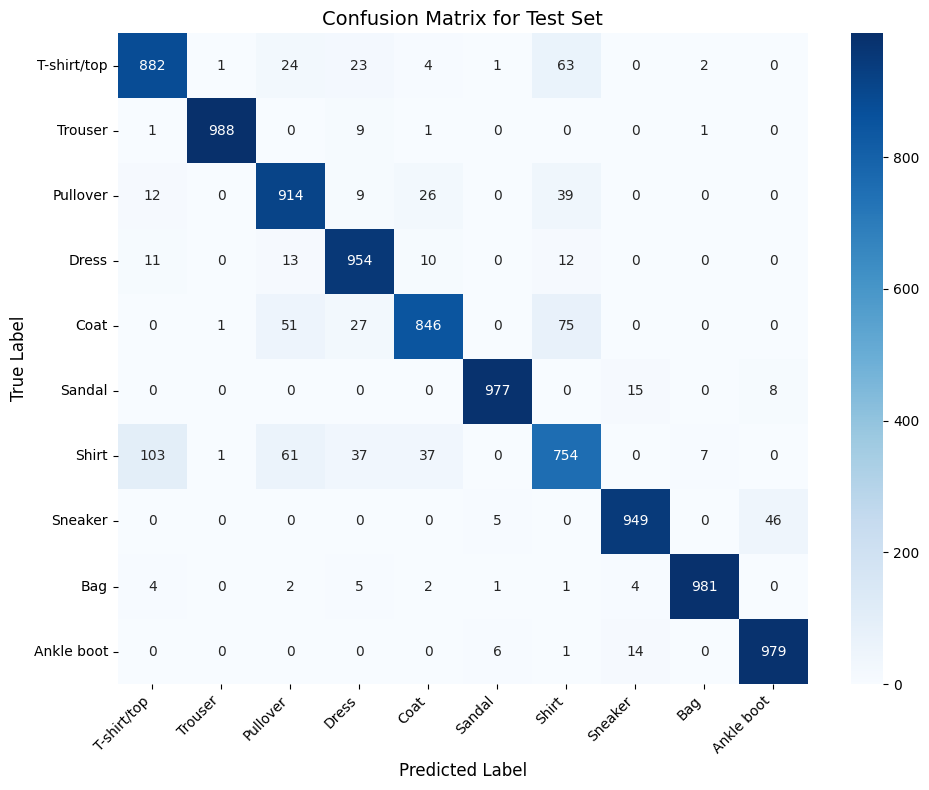

In [51]:
#| echo: false
#| label: fig-confusion-matrix
#| fig-cap: "Confusion matrix showing the classification performance across all ten classes on the test set. The diagonal elements represent correct predictions, while off-diagonal elements indicate misclassifications. This visualization helps identify which classes are most frequently confused with each other."
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=classes, yticklabels=classes)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix for Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Discussion

**Conclusion:** I would use this model in practice for fashion image classification, with appropriate considerations for its limitations.

The CNN model achieves a test accuracy of 91.39%, which exceeds the 90% threshold and demonstrates strong performance on the Fashion-MNIST classification task. The model shows good generalization, as evidenced by the close alignment between training and test accuracy throughout training, indicating minimal overfitting.

**Benefits:** The model provides automated classification of fashion items, which could be valuable for e-commerce applications such as product categorization, inventory management, or recommendation systems. The model is relatively lightweight and can be serialized for deployment. The training process is stable and converges reliably.

**Limitations:** Several important limitations must be considered. First, the model was trained on grayscale 28×28 pixel images, which may not capture fine details or color information that could be important for distinguishing similar items (e.g., distinguishing between shirts and t-shirts). Second, the model's performance on real-world images may degrade if those images differ significantly from the training distribution in terms of lighting, background, or image quality. Third, the confusion matrix reveals that certain classes (such as shirts and pullovers) are more frequently confused, which could be problematic in applications where these distinctions matter. Fourth, the model does not provide uncertainty estimates, making it difficult to identify when the model is uncertain about a prediction.

**Considerations for Production:** Before deploying this model, I would recommend: (1) collecting and evaluating performance on real-world images that match the intended use case, (2) implementing confidence thresholds to flag uncertain predictions for human review, (3) monitoring model performance over time to detect distribution shift, and (4) considering data augmentation or transfer learning to improve robustness. The model's 91.39% accuracy suggests it would be useful for many applications, but the limitations around image resolution and potential class confusion should be carefully evaluated against the specific requirements of the deployment scenario.


In [52]:
#| echo: false
model.eval()
example_input = torch.randn(1, 1, 28, 28).to(device)
model_scripted = torch.jit.trace(model, example_input)
model_scripted.save("fashion.pt")
print("Model saved to fashion.pt")

Model saved to fashion.pt
